In [1]:
import matplotlib.pyplot as plt
import numpy as np

from spd.sdfb_simulator import SDFB_Simulator

In [2]:
T = 1.0

use_cupy = True

p_values = [0, 1, 2]
element_counts = [16, 32, 64]

In [3]:
def sine_wave(xy: np.ndarray, case: int):
    x = xy[0]
    y = xy[1]

    if case == 0:
        # density
        return 1.5 + np.sin(2 * np.pi * (x + y))
    elif case == 1:
        # vx
        return np.ones(x.shape)
    elif case == 2:
        # vy
        return np.ones(x.shape)
    elif case == 4:
        # Pressure
        return np.ones(x.shape)
    else:
        return np.zeros(x.shape)


def run_case(N: int, p: int):
    print(f"{N=}, {p=}")

    sim = SDFB_Simulator(
        N=(N // (p + 1), N // (p + 1)),
        init_fct=sine_wave,
        scheme="SDFB",  # no fallback, so no limiting
        p=p,
        cfl_coeff=0.4,
        time_integrator={0: "rk1", 1: "rk2", 2: "rk3"}[p],
        riemann_solver_sd="hllc",
        use_cupy=use_cupy,
    )

    rho_initial = sim.dm.asnumpy(sim.dm.W_cv[0]).copy()

    sim.perform_time_evolution(T)

    rho_final = sim.dm.asnumpy(sim.dm.W_cv[0])
    linf = np.max(np.abs(rho_final - rho_initial))

    return {
        "p": p,
        "N": N // (p + 1),
        "dofs": N,
        "linf": float(linf),
        "steps": sim.n_step,
    }

In [4]:
rows = []

for p in p_values:
    p_rows = []
    for N in element_counts:
        row = run_case(N, p)
        row["rate"] = np.nan
        if p_rows:
            row["rate"] = np.log(p_rows[-1]["linf"] / row["linf"]) / np.log(2)
        rows.append(row)
        p_rows.append(row)

N=16, p=0
t=1.0, steps taken 174, time taken 2.079, bzcps = 0.0
N=32, p=0
t=1.0, steps taken 367, time taken 4.118, bzcps = 0.0
N=64, p=0
t=1.0, steps taken 772, time taken 8.675, bzcps = 0.0
N=16, p=1
t=1.0, steps taken 186, time taken 4.527, bzcps = 0.0
N=32, p=1
t=1.0, steps taken 400, time taken 9.715, bzcps = 0.0
N=64, p=1
t=1.0, steps taken 833, time taken 20.154, bzcps = 0.0
N=16, p=2
t=1.0, steps taken 199, time taken 8.37, bzcps = 0.0
N=32, p=2
t=1.0, steps taken 401, time taken 16.821, bzcps = 0.0
N=64, p=2
t=1.0, steps taken 842, time taken 35.318, bzcps = 0.0


In [7]:
print(f"{'p':>2} {'N':>5} {'dofs':>6} {'steps':>6} {'linf':>13} {'rate':>8}")
for row in rows:
    rate = "--" if np.isnan(row["rate"]) else f"{row['rate']:.3f}"
    print(
        f"{row['p']:2d} {row['N']:5d} {row['dofs']:6d} "
        f"{row['steps']:6d} {row['linf']:13.6e} {rate:>8}"
    )

 p     N   dofs  steps          linf     rate
 0    16     16    174  8.676546e-01       --
 0    32     32    367  6.386024e-01    0.442
 0    64     64    772  4.020216e-01    0.668
 1     8     16    186  5.223728e-01       --
 1    16     32    400  1.915623e-01    1.447
 1    32     64    833  6.855029e-02    1.483
 2     5     16    199  4.142869e-02       --
 2    10     32    401  3.951392e-03    3.390
 2    21     64    842  5.355726e-04    2.883


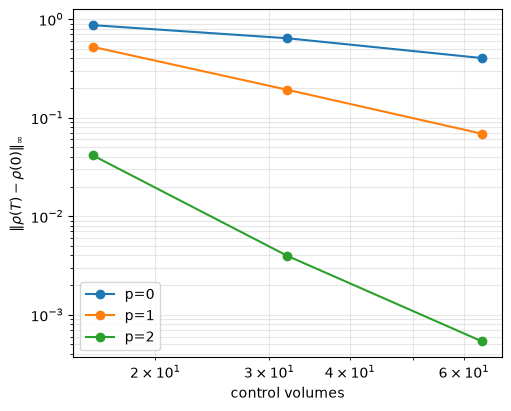

In [8]:
fig, ax = plt.subplots(constrained_layout=True, figsize=(5, 4))
ax.set_xscale("log", base=2)
ax.set_yscale("log")

for p in p_values:
    p_rows = [row for row in rows if row["p"] == p]
    ax.loglog(
        [row["dofs"] for row in p_rows],
        [row["linf"] for row in p_rows],
        "o-",
        label=f"p={p}",
    )

ax.set_xlabel("control volumes")
ax.set_ylabel(r"$\|\rho(T)-\rho(0)\|_\infty$")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.savefig("sine-advection-rk3-linf.png", dpi=300, bbox_inches="tight")